## Flood Risk Classifier

## Problem Statement:
Predict flood risk in districts based on weather and geographic features.

#### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [5]:
df=pd.read_csv("C:/Users/USER/Downloads/urban_pluvial_flood_risk_dataset.csv")
df

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,NaN,78.8,GratedInlet,NaN,46.5,10,monitor
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,NaN,236.1,GratedInlet,NaN,27.7,2,monitor
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying


In [6]:
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


In [7]:
df.shape

(2963, 17)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m       

In [9]:
df.dtypes

segment_id                              object
city_name                               object
admin_ward                              object
latitude                               float64
longitude                              float64
catchment_id                            object
elevation_m                            float64
dem_source                              object
land_use                                object
soil_group                              object
drainage_density_km_per_km2            float64
storm_drain_proximity_m                float64
storm_drain_type                        object
rainfall_source                         object
historical_rainfall_intensity_mm_hr    float64
return_period_years                      int64
risk_labels                             object
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,2963.0,19.399103,24.446320,-36.999038,6.580006,23.760802,37.887422,55.821219
longitude,2963.0,31.676123,79.542482,-123.292949,-43.124581,36.889173,101.701136,174.911271
elevation_m,2802.0,37.689818,38.708958,-3.000000,8.725000,25.130000,59.620000,266.700000
drainage_density_km_per_km2,2679.0,6.290866,2.187365,1.270000,4.670000,6.250000,7.830000,12.070000
storm_drain_proximity_m,2724.0,123.202203,107.764541,0.200000,47.975000,91.700000,162.625000,751.700000
historical_rainfall_intensity_mm_hr,2963.0,43.811441,25.221200,5.400000,25.800000,37.900000,55.550000,150.000000
return_period_years,2963.0,19.730003,25.182883,2.000000,5.000000,10.000000,25.000000,100.000000


In [11]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [12]:
df.isnull().sum()

segment_id                               0
city_name                                0
admin_ward                               0
latitude                                 0
longitude                                0
catchment_id                             0
elevation_m                            161
dem_source                               0
land_use                                 0
soil_group                             362
drainage_density_km_per_km2            284
storm_drain_proximity_m                239
storm_drain_type                       178
rainfall_source                        315
historical_rainfall_intensity_mm_hr      0
return_period_years                      0
risk_labels                              0
dtype: int64

In [13]:
df = df.drop(columns=['segment_id',"catchment_id" ])

## data cleaning & preprocessing

In [14]:
df["elevation_m"].fillna(df["elevation_m"].median(), inplace=True)
df["storm_drain_proximity_m"].fillna(df["storm_drain_proximity_m"].median(), inplace=True)
df["soil_group"].fillna("Unknown", inplace=True)


C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1341625577.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["elevation_m"].fillna(df["elevation_m"].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1341625577.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [15]:
def map_risk(label):
    if pd.isna(label):
        return "Low"
    label = str(label).lower()
    if "ponding_hotspot" in label or "event_" in label or "extreme_rain" in label:
        return "High"
    elif "low_lying" in label or "sparse_drainage" in label:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df["risk_labels"].apply(map_risk)

print("\nClass distribution:\n")
print(df["risk_level"].value_counts())


Class distribution:

risk_level
Low       1991
Medium     495
High       477
Name: count, dtype: int64


In [16]:
categorical_cols = ["land_use", "soil_group", "storm_drain_type", "rainfall_source"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [17]:
numeric_cols = ["elevation_m", "drainage_density_km_per_km2",
                "storm_drain_proximity_m", "historical_rainfall_intensity_mm_hr",
                "return_period_years"]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [18]:
X = df[categorical_cols + numeric_cols]
y = df["risk_level"]

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\306771284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="risk_level", data=df, palette="Set2")


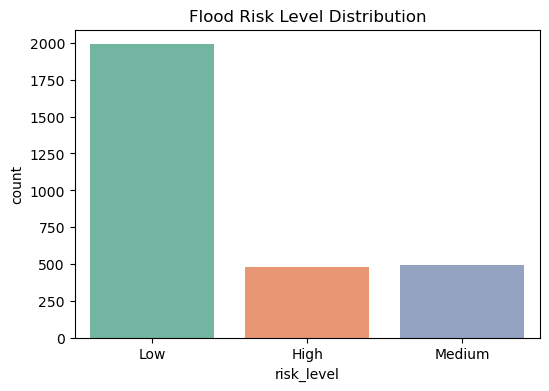

In [19]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="risk_level", data=df, palette="Set2")
plt.title("Flood Risk Level Distribution")
plt.show()

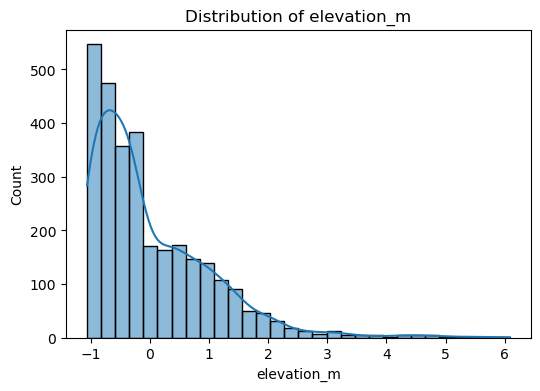

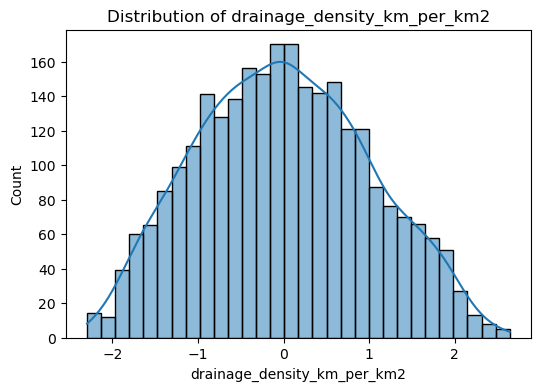

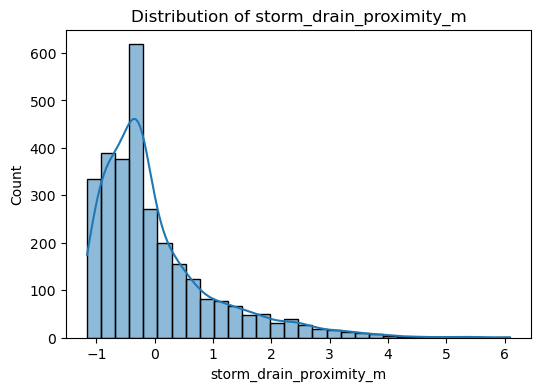

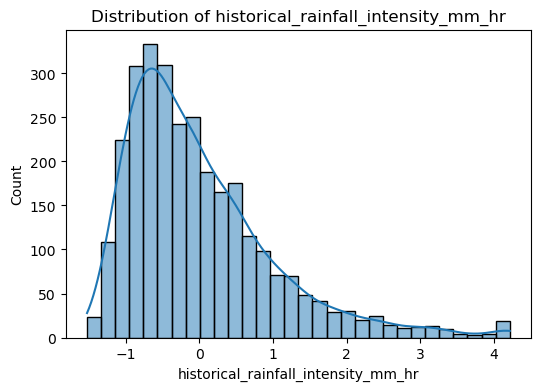

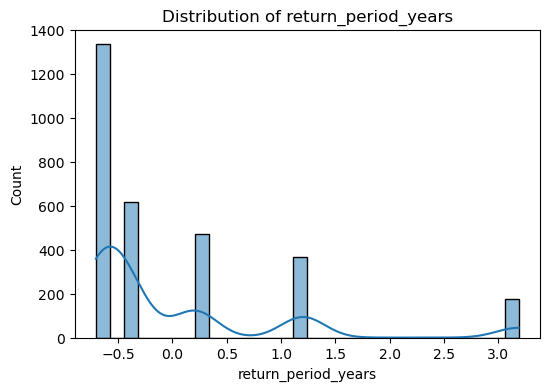

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1699601918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")


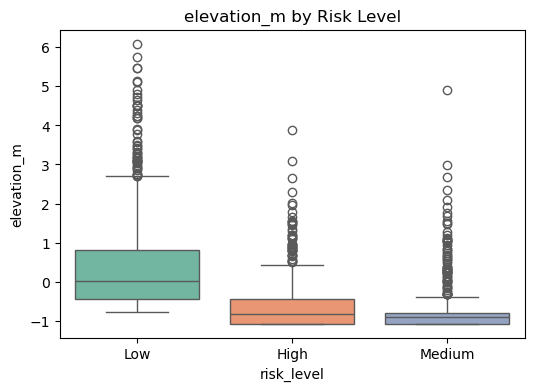

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1699601918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")


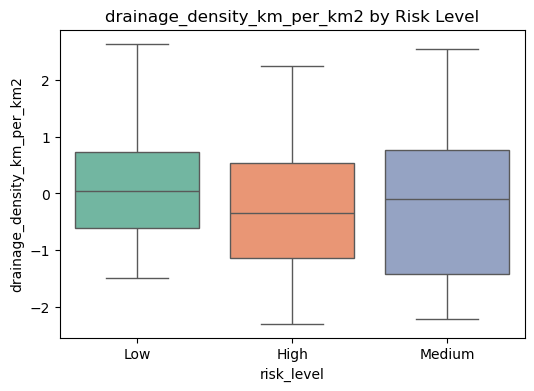

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1699601918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")


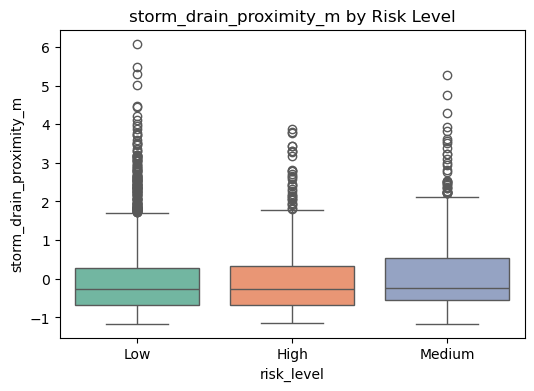

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1699601918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")


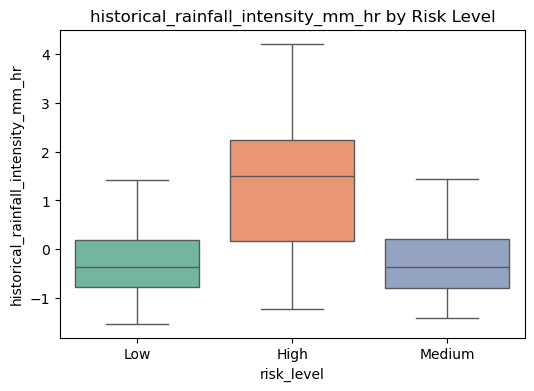

C:\Users\USER\AppData\Local\Temp\ipykernel_12452\1699601918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")


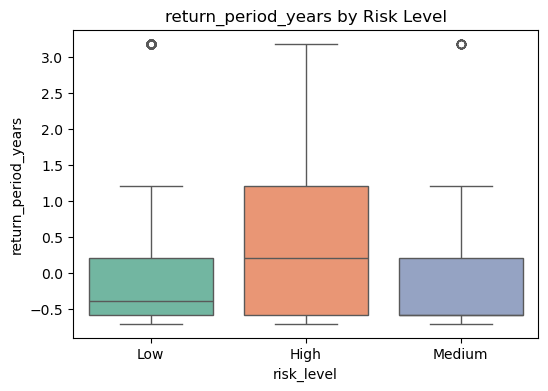

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="risk_level", y=col, data=df, palette="Set2")
    plt.title(f"{col} by Risk Level")
    plt.show()

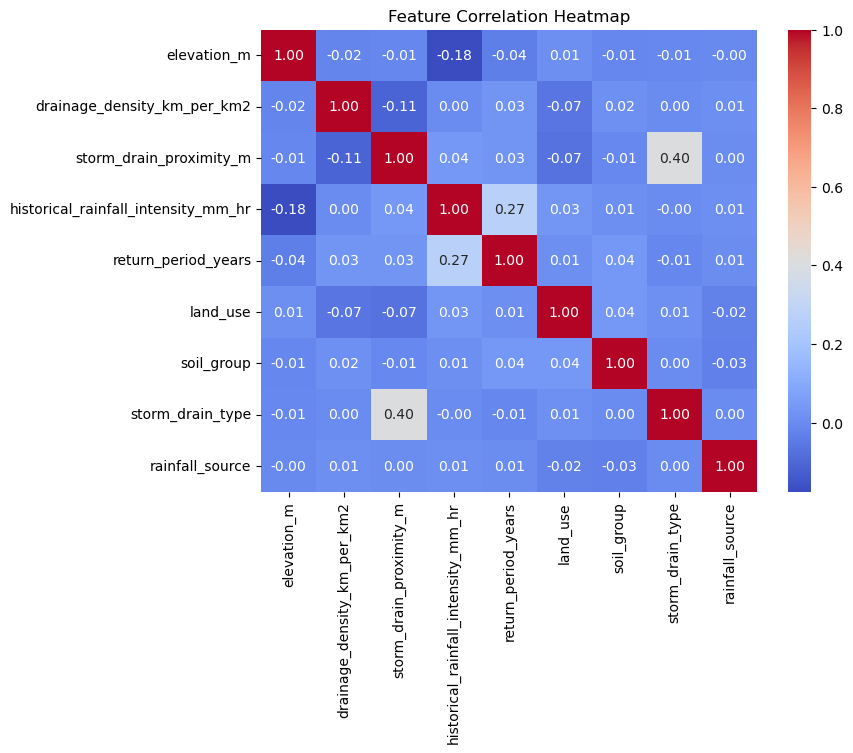

In [22]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols + categorical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## modeling

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_imputed, y_train)
y_pred_lr = log_reg.predict(X_test_imputed)
print("\n🔹 Logistic Regression Results\n", classification_report(y_test, y_pred_lr))


🔹 Logistic Regression Results
               precision    recall  f1-score   support

        High       0.63      0.60      0.61        95
         Low       0.84      0.93      0.89       399
      Medium       0.68      0.40      0.51        99

    accuracy                           0.79       593
   macro avg       0.72      0.65      0.67       593
weighted avg       0.78      0.79      0.78       593



In [31]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n🔹 Random Forest Results\n", classification_report(y_test, y_pred_rf))


🔹 Random Forest Results
               precision    recall  f1-score   support

        High       0.89      0.79      0.84        95
         Low       1.00      1.00      1.00       399
      Medium       0.82      0.91      0.86        99

    accuracy                           0.95       593
   macro avg       0.90      0.90      0.90       593
weighted avg       0.95      0.95      0.95       593



In [36]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train_encoded)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("\n🔹 XGBoost Results\n")
print(classification_report(y_test_encoded, y_pred_xgb))

C:\Users\USER\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:24:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔹 XGBoost Results

              precision    recall  f1-score   support

           0       0.89      0.81      0.85        95
           1       1.00      0.99      1.00       399
           2       0.84      0.92      0.88        99

    accuracy                           0.95       593
   macro avg       0.91      0.91      0.91       593
weighted avg       0.95      0.95      0.95       593



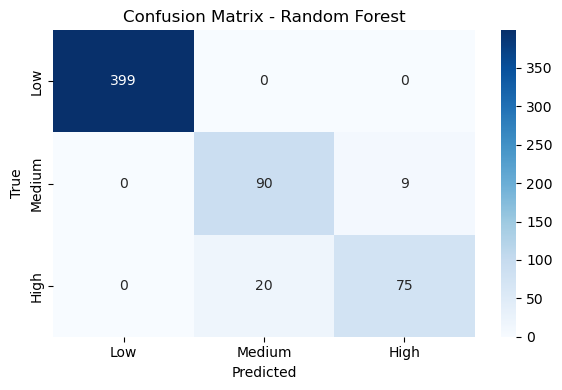

In [37]:
cm = confusion_matrix(y_test, y_pred_rf, labels=["Low", "Medium", "High"])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_12452\2780999356.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")


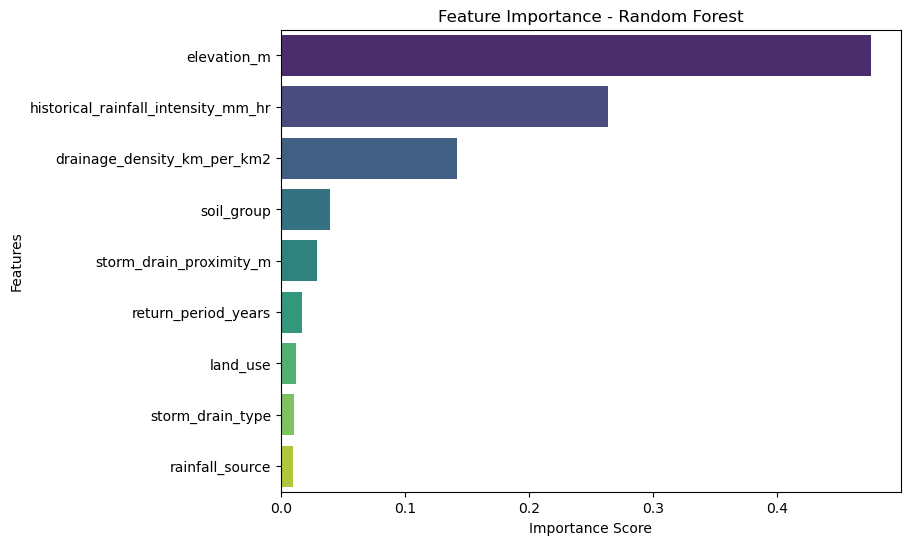

In [38]:
importances = rf.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()